First 5 Rows:
   age  income  expenses  savings   debt risk_tolerance
0   50   74813     88822    66610  11989            Low
1   36   67198     20901     6401  13780           High
2   29   38820     46552    20193   6589         Medium
3   42   54070     46055    49864  34812            Low
4   40   99768     52685    25307  28128         Medium

Dataset Shape:
(1200, 6)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             1200 non-null   int64 
 1   income          1200 non-null   int64 
 2   expenses        1200 non-null   int64 
 3   savings         1200 non-null   int64 
 4   debt            1200 non-null   int64 
 5   risk_tolerance  1200 non-null   object
dtypes: int64(5), object(1)
memory usage: 56.4+ KB
None

Statistical Summary:
               age         income      expenses       savings          de

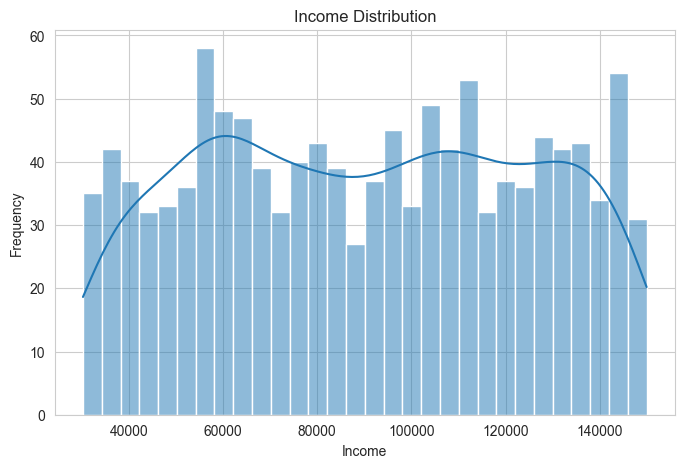

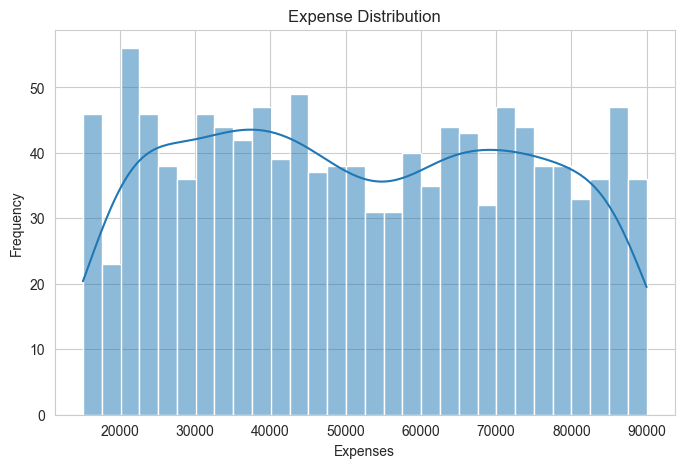

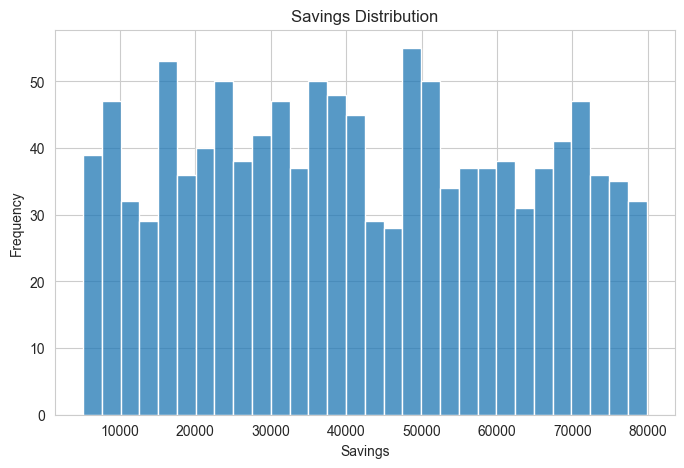

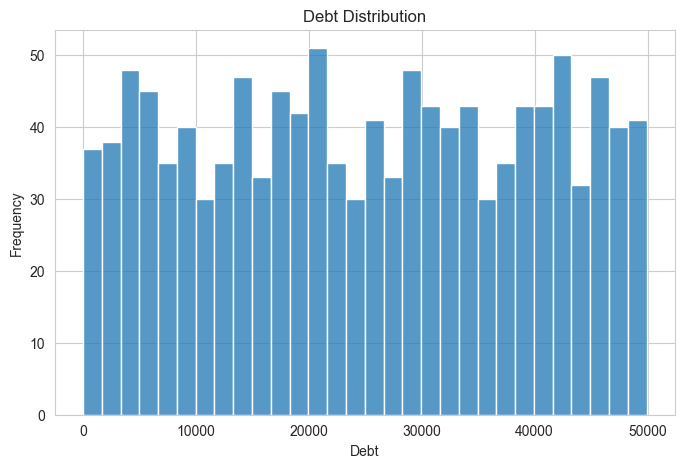

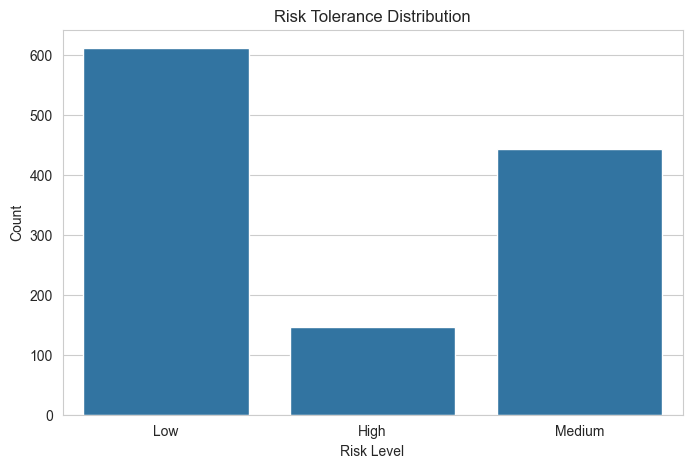

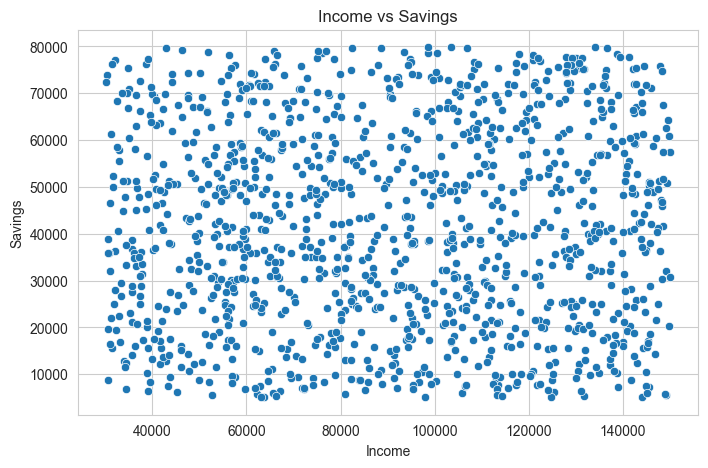

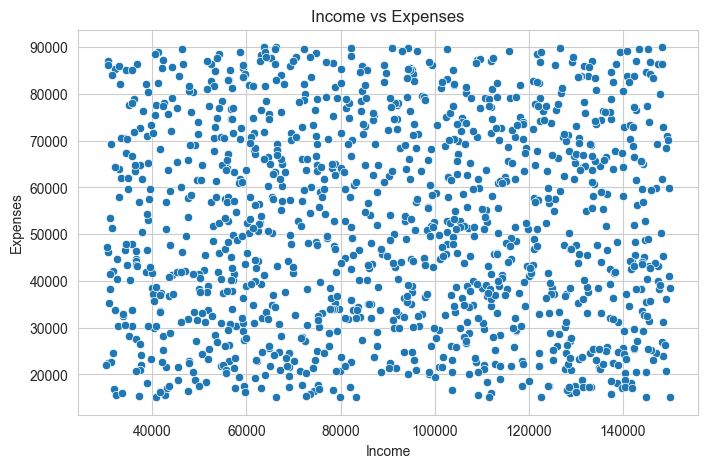

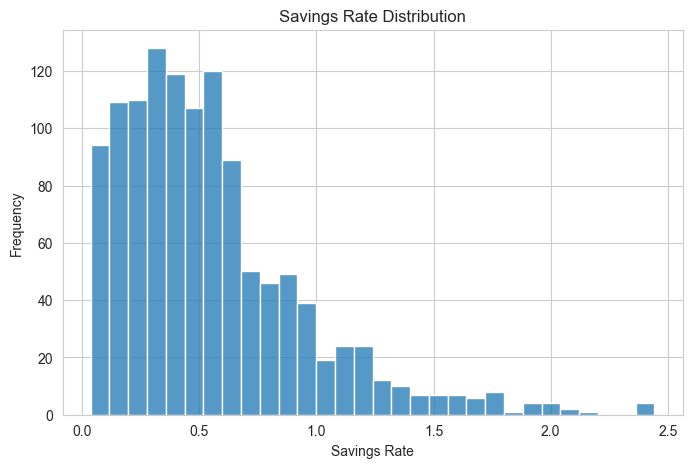

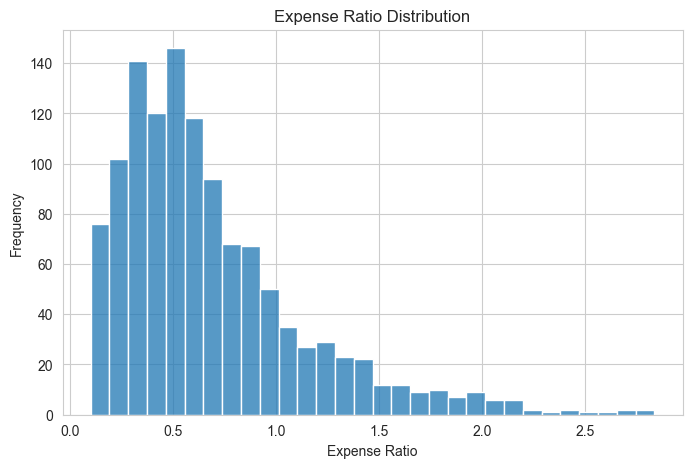

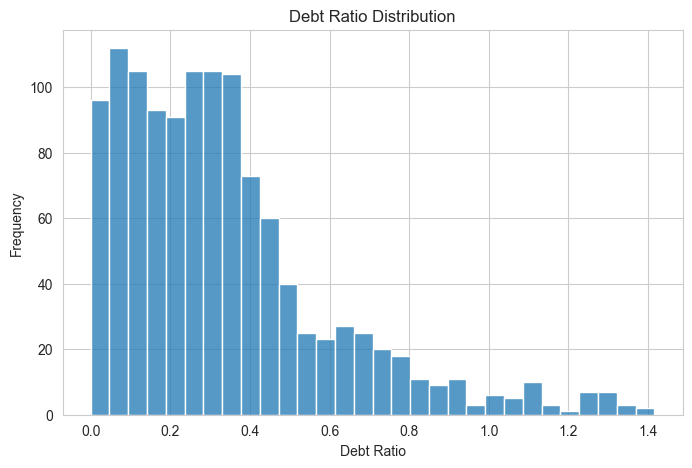

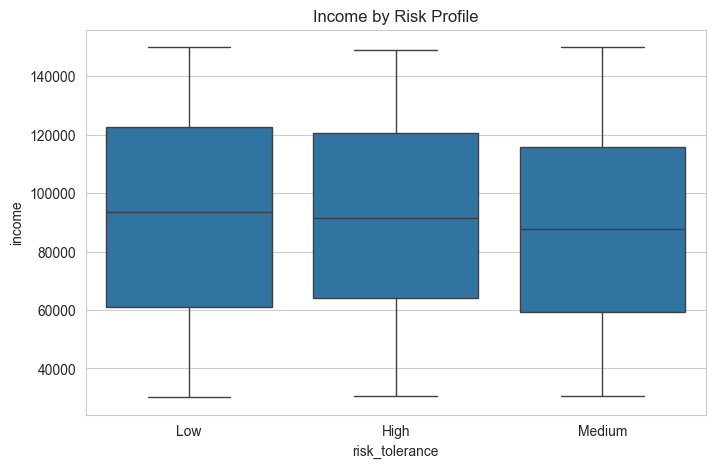

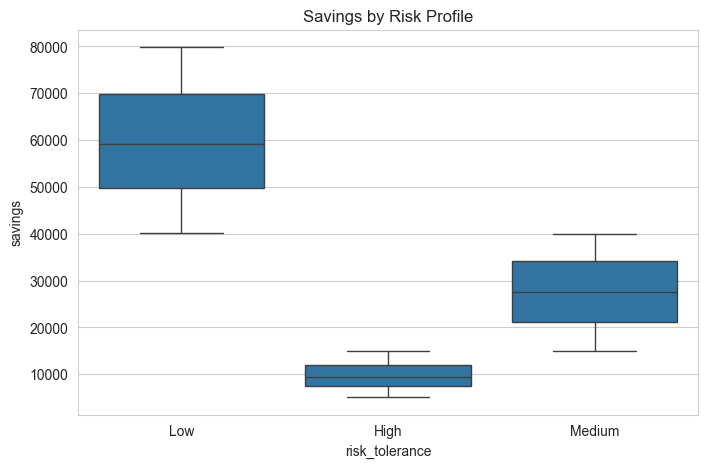

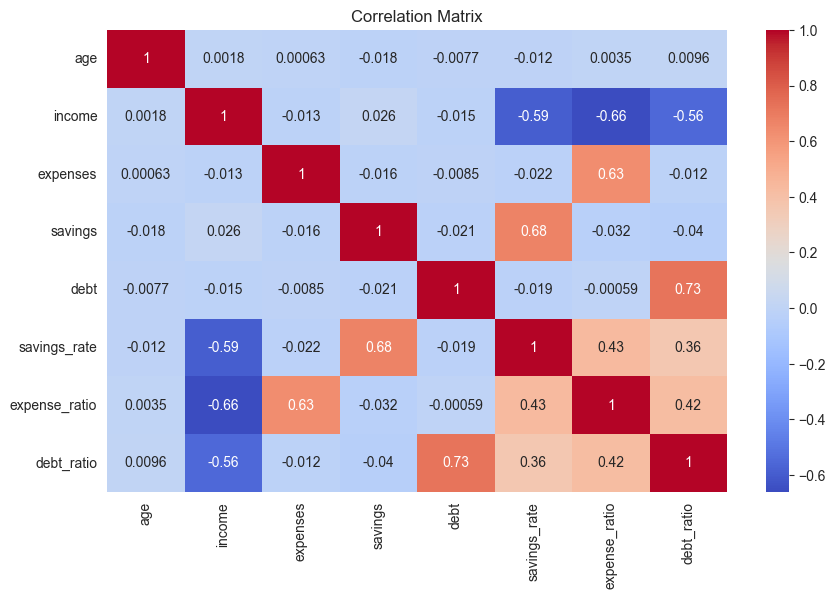

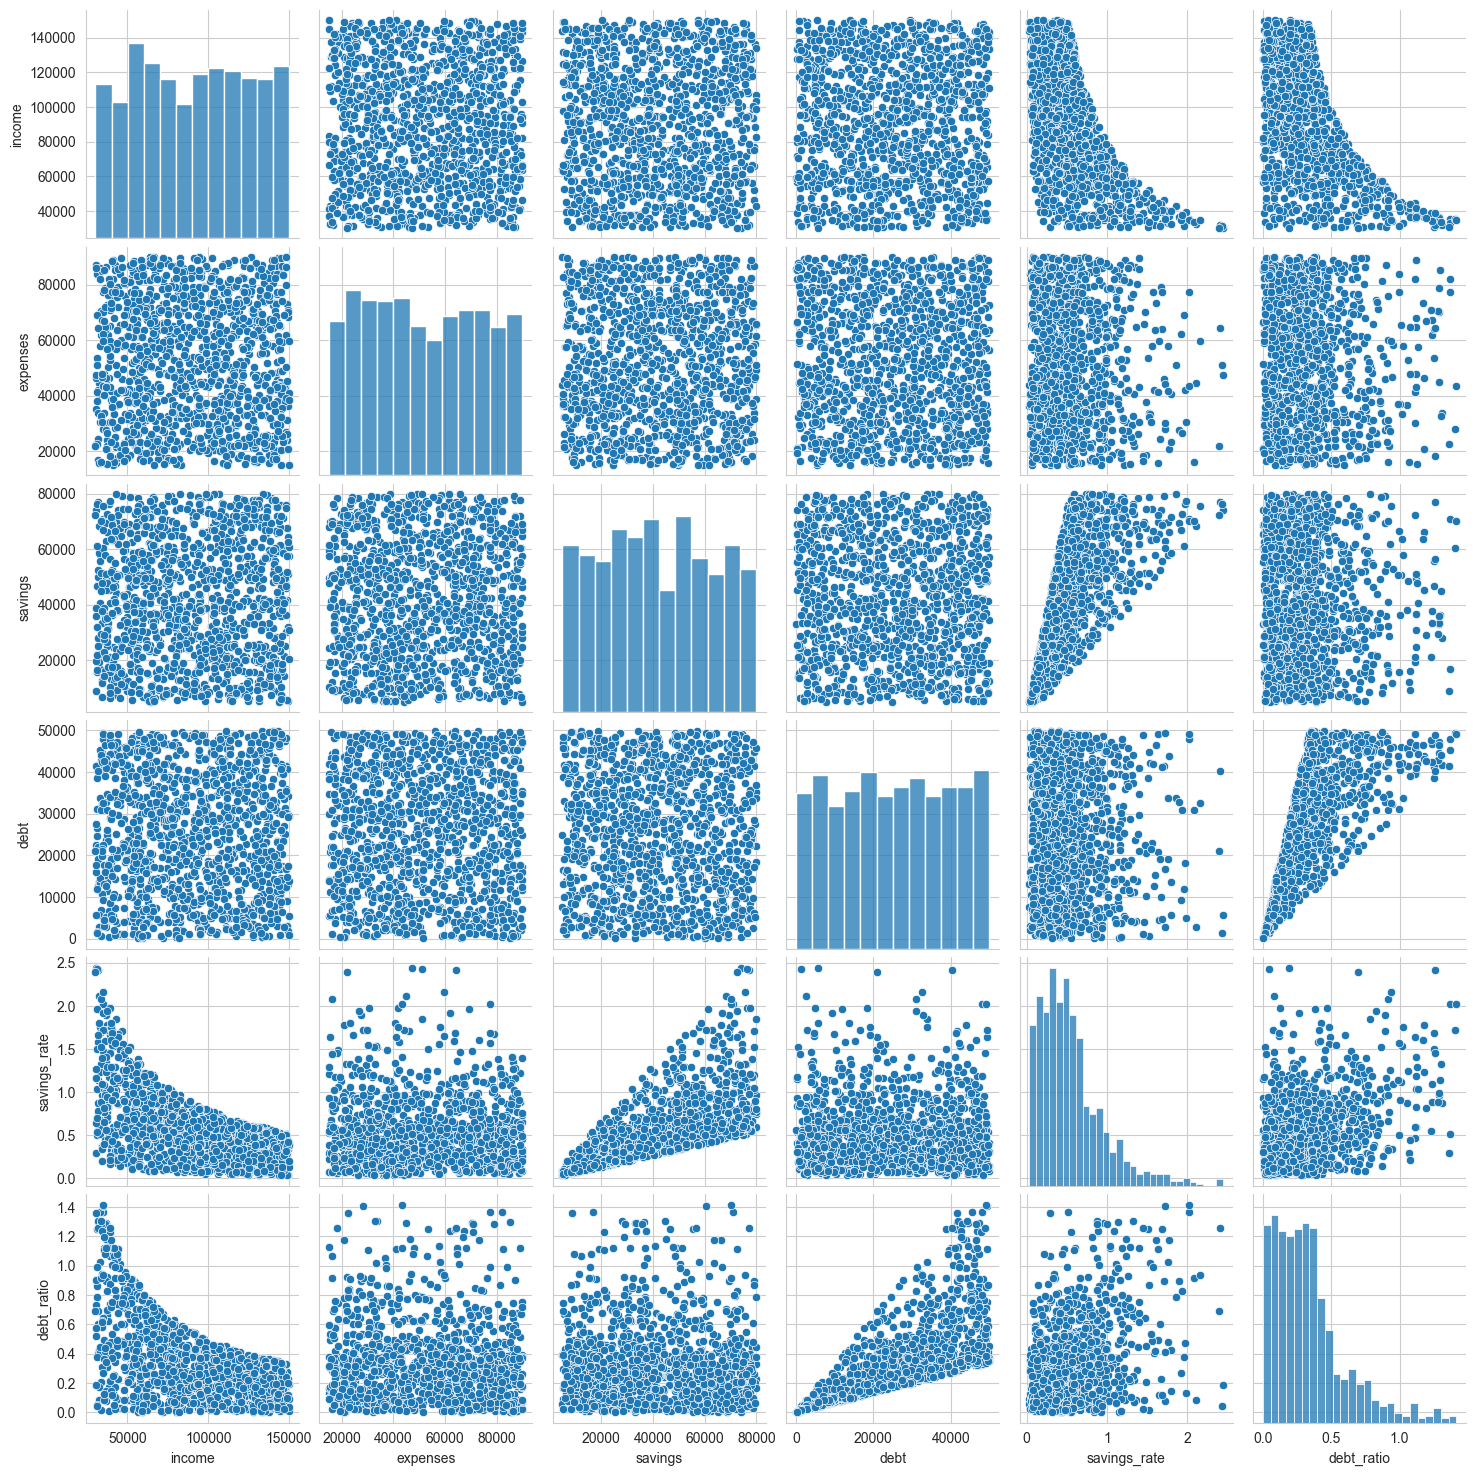


Financial Segment Counts:
financial_segment
High Saver      560
Medium Saver    286
Low Saver       214
Name: count, dtype: int64


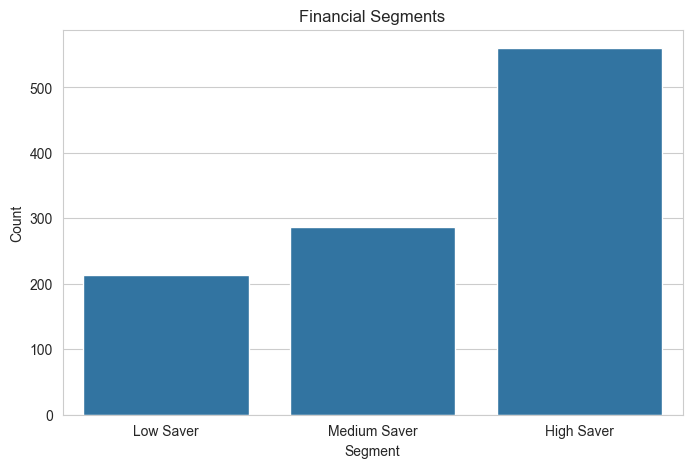


Key Insights:
1. Higher income individuals tend to have higher savings.
2. Debt ratio influences financial stability.
3. Savings rate is a strong indicator of financial health.
4. Risk tolerance varies depending on savings and income patterns.

Processed dataset saved successfully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

#Load Dataset

df = pd.read_csv("../data/financial_data.csv")

print("First 5 Rows:")
print(df.head())

#Dataset Shape

print("\nDataset Shape:")
print(df.shape)

#Dataset Information

print("\nDataset Info:")
print(df.info())

##Statistical Summary

print("\nStatistical Summary:")
print(df.describe())

#Check Missing Values

print("\nMissing Values:")
print(df.isnull().sum())

#Create Financial Features

df["savings_rate"] = df["savings"] / df["income"]
df["expense_ratio"] = df["expenses"] / df["income"]
df["debt_ratio"] = df["debt"] / df["income"]

print("\nDataset After Feature Engineering:")
print(df.head())

# -------------------------------
# DATA VISUALIZATIONS
# -------------------------------
# Income Distribution

plt.figure()
sns.histplot(df["income"], bins=30, kde=True)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

#Expense Distribution

plt.figure()
sns.histplot(df["expenses"], bins=30, kde=True)
plt.title("Expense Distribution")
plt.xlabel("Expenses")
plt.ylabel("Frequency")
plt.show()

#Savings Distribution

plt.figure()
sns.histplot(df["savings"], bins=30)
plt.title("Savings Distribution")
plt.xlabel("Savings")
plt.ylabel("Frequency")
plt.show()

#Debt Distribution

plt.figure()
sns.histplot(df["debt"], bins=30)
plt.title("Debt Distribution")
plt.xlabel("Debt")
plt.ylabel("Frequency")
plt.show()

#Risk Tolerance Distribution

plt.figure()
sns.countplot(x="risk_tolerance", data=df)
plt.title("Risk Tolerance Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

#Income vs Savings

plt.figure()
sns.scatterplot(x="income", y="savings", data=df)
plt.title("Income vs Savings")
plt.xlabel("Income")
plt.ylabel("Savings")
plt.show()

# Income vs Expenses

plt.figure()
sns.scatterplot(x="income", y="expenses", data=df)
plt.title("Income vs Expenses")
plt.xlabel("Income")
plt.ylabel("Expenses")
plt.show()

# Savings Rate Distribution

plt.figure()
sns.histplot(df["savings_rate"], bins=30)
plt.title("Savings Rate Distribution")
plt.xlabel("Savings Rate")
plt.ylabel("Frequency")
plt.show()

# Expense Ratio Distribution

plt.figure()
sns.histplot(df["expense_ratio"], bins=30)
plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio")
plt.ylabel("Frequency")
plt.show()

# Debt Ratio Distribution

plt.figure()
sns.histplot(df["debt_ratio"], bins=30)
plt.title("Debt Ratio Distribution")
plt.xlabel("Debt Ratio")
plt.ylabel("Frequency")
plt.show()

# Income by Risk Profile

plt.figure()
sns.boxplot(x="risk_tolerance", y="income", data=df)
plt.title("Income by Risk Profile")
plt.show()

# Savings by Risk Profile

plt.figure()
sns.boxplot(x="risk_tolerance", y="savings", data=df)
plt.title("Savings by Risk Profile")
plt.show()

# Correlation Matrix

plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Pair Plot

sns.pairplot(df[
[
"income",
"expenses",
"savings",
"debt",
"savings_rate",
"debt_ratio"
]
])
plt.show()

# Financial Segmentation Based on Savings Rate

df["financial_segment"] = pd.cut(
df["savings_rate"],
bins=[0,0.2,0.4,1],
labels=["Low Saver","Medium Saver","High Saver"]
)

print("\nFinancial Segment Counts:")
print(df["financial_segment"].value_counts())

# Visualize Financial Segments

plt.figure()
sns.countplot(x="financial_segment", data=df)
plt.title("Financial Segments")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

# Insights

print("\nKey Insights:")
print("1. Higher income individuals tend to have higher savings.")
print("2. Debt ratio influences financial stability.")
print("3. Savings rate is a strong indicator of financial health.")
print("4. Risk tolerance varies depending on savings and income patterns.")

# Save Processed Dataset

df.to_csv("../data/processed_financial_data.csv", index=False)

print("\nProcessed dataset saved successfully.")